In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

SILVER_FILE = "data/silver/silver_databridge.csv"
OUT_DIR     = "data/gold"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configurações aplicadas ✅")

Configurações aplicadas ✅


In [4]:
df = pd.read_csv('../silver_layer/silver_databridge.csv')

taxa_geral = df["default_12m"].mean() * 100
print(f"Registros    : {len(df):,}")
print(f"Inadimplentes: {df['default_12m'].sum():,} ({taxa_geral:.1f}%)")

Registros    : 24,974
Inadimplentes: 4,152 (16.6%)


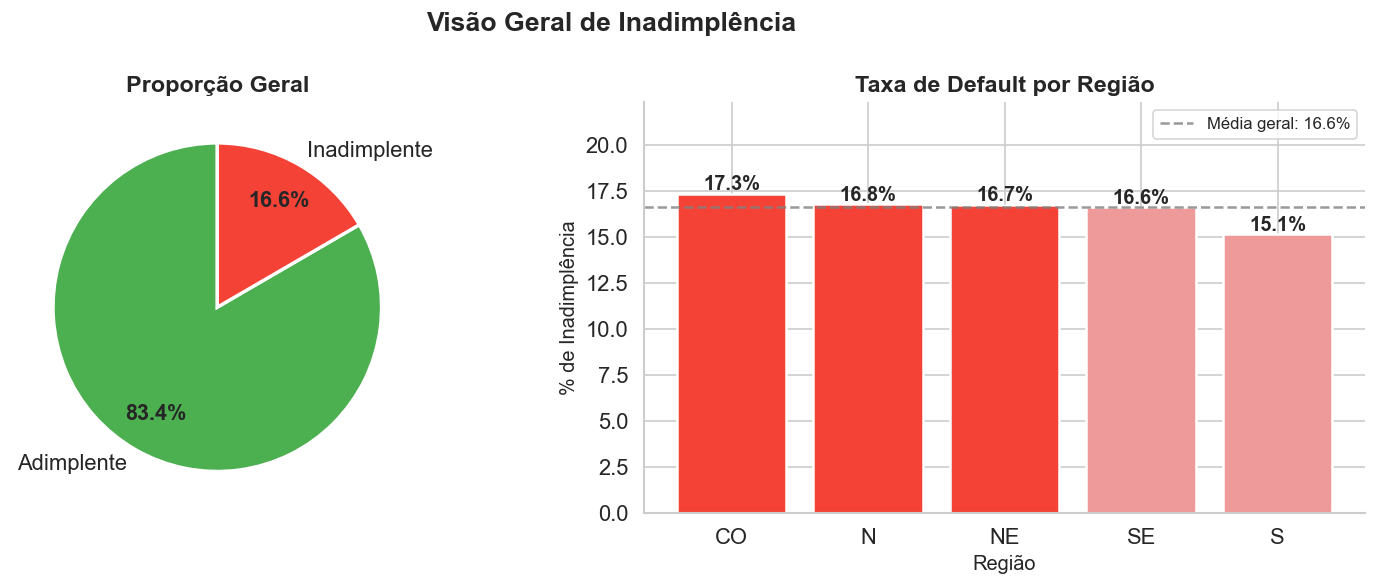

In [5]:
contagem = df["default_12m"].value_counts().sort_index()
labels   = ["Adimplente", "Inadimplente"]
cores    = ["#4caf50", "#f44336"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Visão Geral de Inadimplência", fontsize=16, fontweight="bold")

# Pizza
wedges, texts, autotexts = axes[0].pie(
    contagem.values, labels=labels, colors=cores,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
axes[0].set_title("Proporção Geral")

# Por região
def_regiao = df.groupby("regiao")["default_12m"].mean() * 100
def_regiao = def_regiao.sort_values(ascending=False)
cores_bar  = ["#f44336" if v >= taxa_geral else "#ef9a9a" for v in def_regiao.values]
bars = axes[1].bar(def_regiao.index, def_regiao.values,
                   color=cores_bar, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, def_regiao.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
axes[1].axhline(y=taxa_geral, color="gray", linestyle="--",
                alpha=0.8, label=f"Média geral: {taxa_geral:.1f}%")
axes[1].set_title("Taxa de Default por Região")
axes[1].set_ylabel("% de Inadimplência")
axes[1].set_xlabel("Região")
axes[1].set_ylim(0, def_regiao.max() + 5)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/inadimplencia_01_visao_geral.png", bbox_inches="tight")
plt.show()

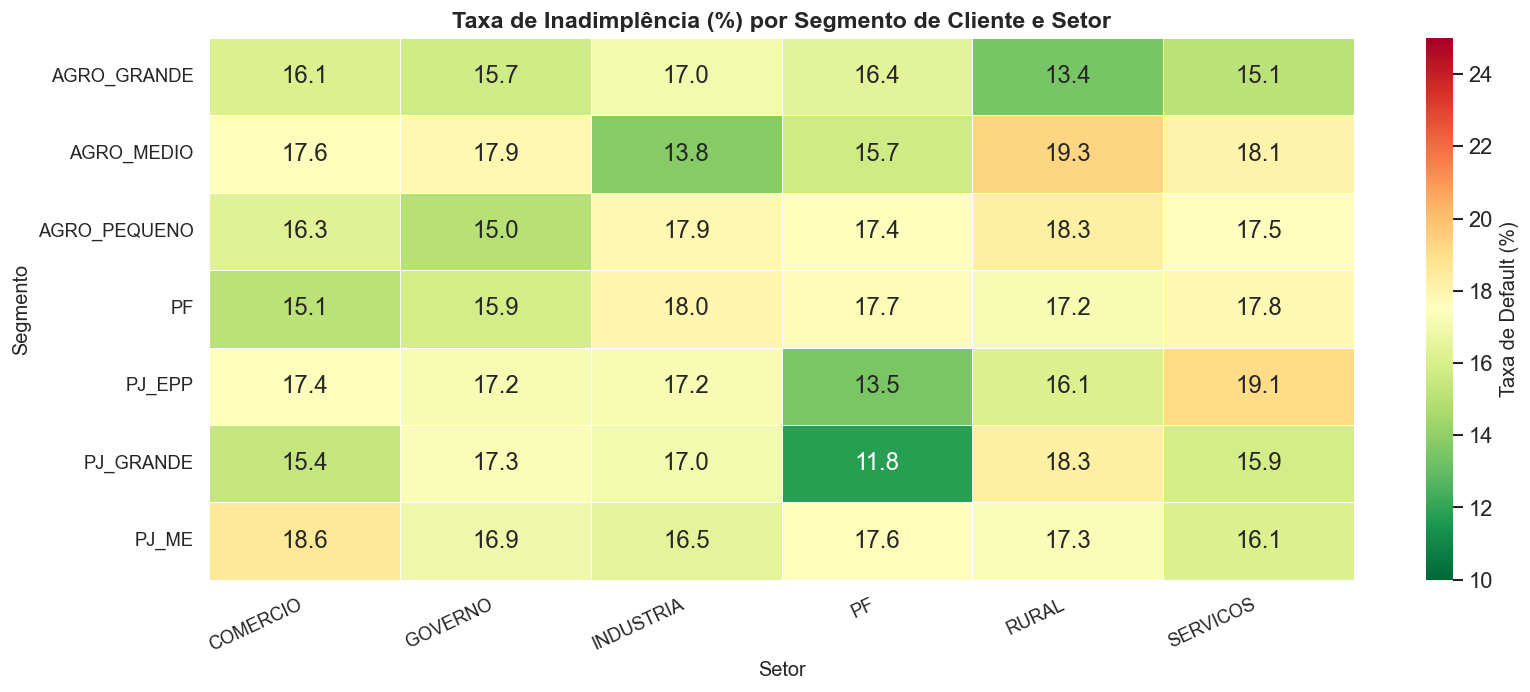

In [6]:
pivot_setor = (
    df.groupby(["customer_segment", "industry_sector"], observed=True)["default_12m"]
    .mean()
    .unstack()
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_setor,
    annot=True, fmt=".1f", cmap="RdYlGn_r",
    vmin=10, vmax=25,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Taxa de Default (%)"},
    ax=ax
)
ax.set_title("Taxa de Inadimplência (%) por Segmento de Cliente e Setor")
ax.set_xlabel("Setor")
ax.set_ylabel("Segmento")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/inadimplencia_02_segmento_setor.png", bbox_inches="tight")
plt.show()

C:\Users\Marce\AppData\Local\Temp\ipykernel_10864\53524326.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(def_garantia["collateral_type"], rotation=15, ha="right")
C:\Users\Marce\AppData\Local\Temp\ipykernel_10864\53524326.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(def_garantia["collateral_type"], rotation=15, ha="right")


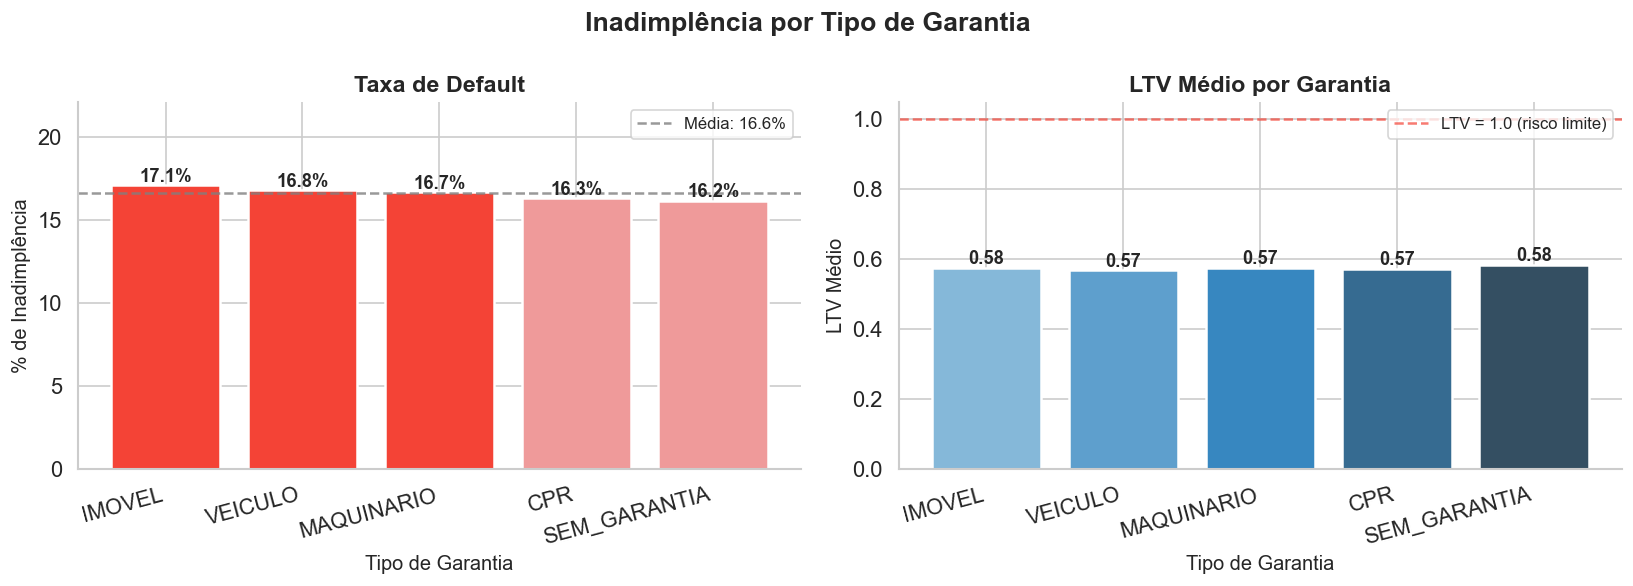

In [7]:
def_garantia = (
    df.groupby("collateral_type", observed=True)
    .agg(
        total        = ("default_12m", "count"),
        default_rate = ("default_12m", "mean"),
        ltv_medio    = ("ltv", "mean"),
    )
    .round(4)
    .reset_index()
    .sort_values("default_rate", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Inadimplência por Tipo de Garantia", fontsize=16, fontweight="bold")

cores = ["#f44336" if v >= taxa_geral/100 else "#ef9a9a"
         for v in def_garantia["default_rate"].values]

# Default rate
bars = axes[0].bar(def_garantia["collateral_type"],
                   def_garantia["default_rate"] * 100,
                   color=cores, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, def_garantia["default_rate"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{val*100:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[0].axhline(y=taxa_geral, color="gray", linestyle="--",
                alpha=0.8, label=f"Média: {taxa_geral:.1f}%")
axes[0].set_title("Taxa de Default")
axes[0].set_ylabel("% de Inadimplência")
axes[0].set_xlabel("Tipo de Garantia")
axes[0].set_xticklabels(def_garantia["collateral_type"], rotation=15, ha="right")
axes[0].set_ylim(0, def_garantia["default_rate"].max() * 100 + 5)
axes[0].legend(fontsize=10)

# LTV médio
bars2 = axes[1].bar(def_garantia["collateral_type"],
                    def_garantia["ltv_medio"],
                    color=sns.color_palette("Blues_d", len(def_garantia)),
                    edgecolor="white", linewidth=1.5)
for bar, val in zip(bars2, def_garantia["ltv_medio"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
axes[1].axhline(y=1.0, color="#f44336", linestyle="--",
                alpha=0.7, label="LTV = 1.0 (risco limite)")
axes[1].set_title("LTV Médio por Garantia")
axes[1].set_ylabel("LTV Médio")
axes[1].set_xlabel("Tipo de Garantia")
axes[1].set_xticklabels(def_garantia["collateral_type"], rotation=15, ha="right")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/inadimplencia_03_garantia.png", bbox_inches="tight")
plt.show()

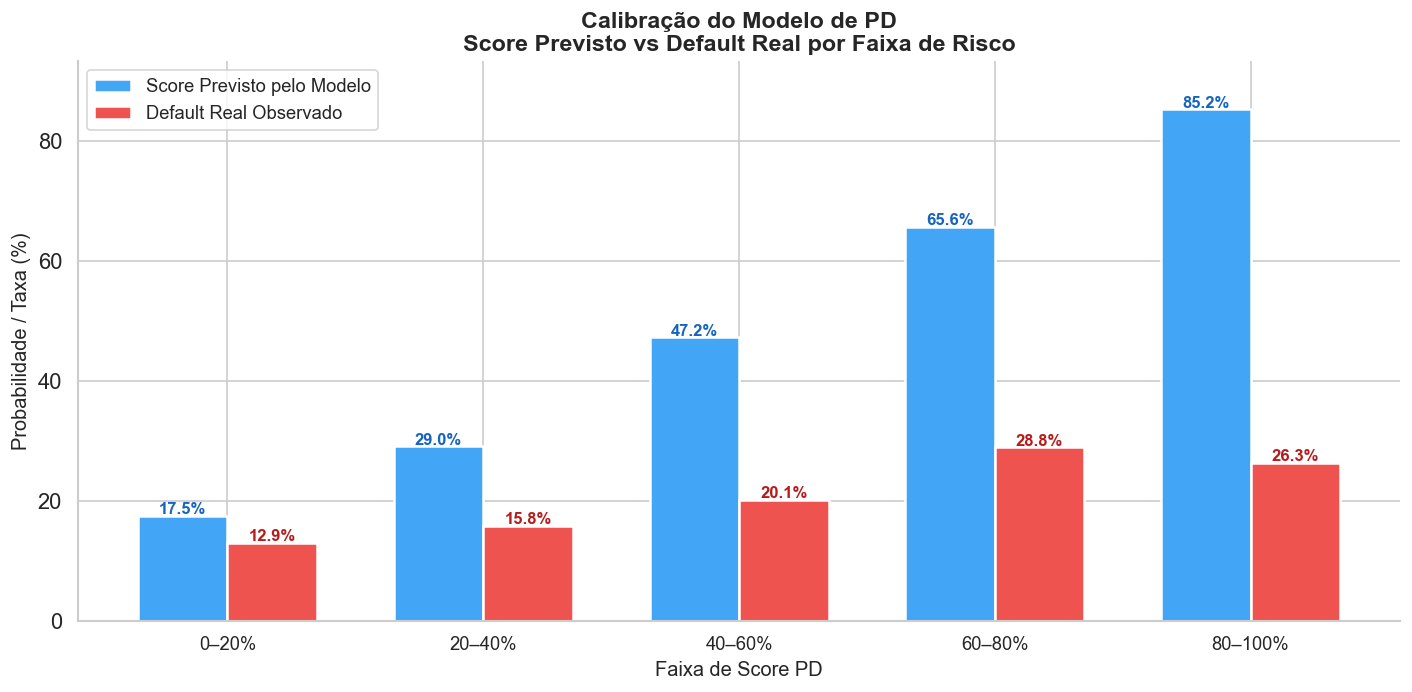


Diferença entre score previsto e default real:
pd_faixa  pd_score_medio  default_rate_real  diferenca
   0–20%          0.1747             0.1290       4.57
  20–40%          0.2905             0.1578      13.27
  40–60%          0.4721             0.2008      27.13
  60–80%          0.6565             0.2885      36.80
 80–100%          0.8523             0.2632      58.91


In [8]:
df["pd_faixa"] = pd.cut(
    df["pd_model_score"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"]
)

calibracao = (
    df.groupby("pd_faixa", observed=True)
    .agg(
        total             = ("default_12m", "count"),
        pd_score_medio    = ("pd_model_score", "mean"),
        default_rate_real = ("default_12m", "mean"),
    )
    .round(4)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(calibracao))
w = 0.35

bars1 = ax.bar(x - w/2, calibracao["pd_score_medio"] * 100, w,
               label="Score Previsto pelo Modelo", color="#42a5f5",
               edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + w/2, calibracao["default_rate_real"] * 100, w,
               label="Default Real Observado", color="#ef5350",
               edgecolor="white", linewidth=1.5)

for bar, val in zip(bars1, calibracao["pd_score_medio"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val*100:.1f}%", ha="center", fontsize=10, fontweight="bold", color="#1565c0")
for bar, val in zip(bars2, calibracao["default_rate_real"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val*100:.1f}%", ha="center", fontsize=10, fontweight="bold", color="#b71c1c")

ax.set_xticks(x)
ax.set_xticklabels(calibracao["pd_faixa"], fontsize=11)
ax.set_title("Calibração do Modelo de PD\nScore Previsto vs Default Real por Faixa de Risco")
ax.set_ylabel("Probabilidade / Taxa (%)")
ax.set_xlabel("Faixa de Score PD")
ax.legend(fontsize=11)
ax.set_ylim(0, max(calibracao[["pd_score_medio","default_rate_real"]].max()) * 100 + 8)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/inadimplencia_04_calibracao.png", bbox_inches="tight")
plt.show()

print("\nDiferença entre score previsto e default real:")
calibracao["diferenca"] = ((calibracao["pd_score_medio"] - calibracao["default_rate_real"]) * 100).round(2)
print(calibracao[["pd_faixa","pd_score_medio","default_rate_real","diferenca"]].to_string(index=False))

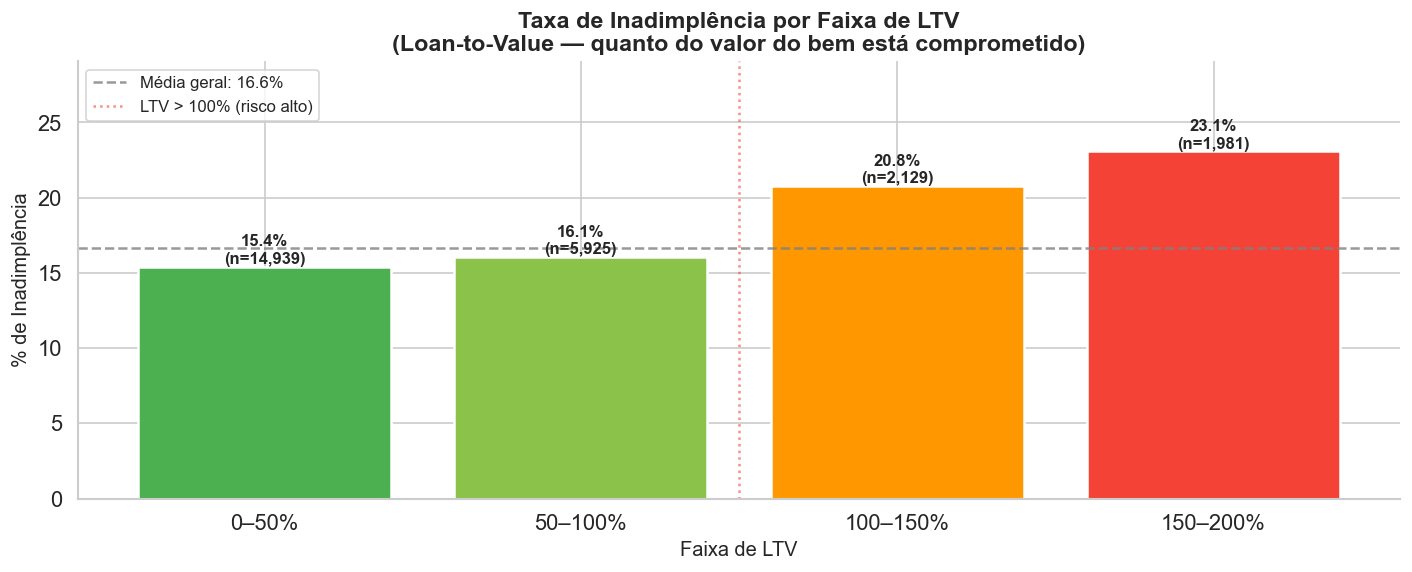

In [9]:
df["ltv_faixa"] = pd.cut(
    df["ltv"],
    bins=[0, 0.5, 1.0, 1.5, 2.0, df["ltv"].max() + 0.01],
    labels=["0–50%", "50–100%", "100–150%", "150–200%", ">200%"]
)

ltv_default = (
    df.groupby("ltv_faixa", observed=True)
    .agg(
        total        = ("default_12m", "count"),
        default_rate = ("default_12m", "mean"),
        ltv_medio    = ("ltv", "mean"),
    )
    .round(4)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
cores_ltv = ["#4caf50", "#8bc34a", "#ff9800", "#f44336", "#b71c1c"]
bars = ax.bar(ltv_default["ltv_faixa"], ltv_default["default_rate"] * 100,
              color=cores_ltv, edgecolor="white", linewidth=1.5)

for bar, row in zip(bars, ltv_default.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{row.default_rate*100:.1f}%\n(n={row.total:,})",
            ha="center", fontsize=10, fontweight="bold")

ax.axhline(y=taxa_geral, color="gray", linestyle="--",
           alpha=0.8, label=f"Média geral: {taxa_geral:.1f}%")
ax.axvline(x=1.5, color="#f44336", linestyle=":", alpha=0.6, label="LTV > 100% (risco alto)")
ax.set_title("Taxa de Inadimplência por Faixa de LTV\n(Loan-to-Value — quanto do valor do bem está comprometido)")
ax.set_ylabel("% de Inadimplência")
ax.set_xlabel("Faixa de LTV")
ax.set_ylim(0, ltv_default["default_rate"].max() * 100 + 6)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/inadimplencia_05_ltv.png", bbox_inches="tight")
plt.show()